# Metadata Models

In [1]:
%load_ext autoreload
%autoreload 2

### Import Libraries

In [42]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve, 
    make_scorer, 
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

from mra_midas_skin_cancer_ml.utils.process_metadata import (
    create_lesion_key,
    dedupe_metadata,
    drop_na_target_img,
    import_metadata,
    process_target,
    get_data_dir,
    export_metadata,
)

from mra_midas_skin_cancer_ml.utils.nlp_functions import (
    basic_clean_clinical_text, 
    add_note_embeddings_tfidf_svd,
    svd_top_phrases,
    apply_note_embeddings_tfidf_svd,
)

from mra_midas_skin_cancer_ml.utils.validate_data import (
    check_split_ratios,
    count_files_in_image_folders,
)

In [3]:
meta_df = import_metadata()
meta_df = process_target(meta_df)
dedupe_df = dedupe_metadata(meta_df)

Is unique: True
Unique count: 1146 



### Split Data into Train/Val/Test

Use patient\-lesion key from the split\_image\_data output to align with image\-only models\. 

In [4]:
split_lookup_path = 'master_lesion_split_lookup.xlsx'
lesion_split_lookup = pd.read_excel(split_lookup_path)
metadata_df = dedupe_df.merge(
    lesion_split_lookup[['lesion_key', 'split']], 
    on='lesion_key',
    how='inner'
)

metadata_df

,midas_path_binary,midas_record_id,midas_location,midas_age,midas_fitzpatrick,midas_race,length_(mm),width_(mm),lesion_key,split
0,malignant,1,chest,80,"ii fair skin, blue eyes",white,8.0,5.0,1_chest_8.0x5.0,train
1,benign,1,l lower back,80,"ii fair skin, blue eyes",white,6.0,5.0,1_l lower back_6.0x5.0,train
2,benign,1,left upper buttock,80,"ii fair skin, blue eyes",white,5.0,3.0,1_left upper buttock_5.0x3.0,test
3,benign,2,right upper eyelid,34,"ii fair skin, blue eyes",white,4.0,2.0,2_right upper eyelid_4.0x2.0,test
4,benign,4,left upper back,47,"i pale white skin, blue/green eyes, blond/red ...",white,5.0,3.0,4_left upper back_5.0x3.0,train
...,...,...,...,...,...,...,...,...,...,...
1030,malignant,805,mid upper back,81,"ii fair skin, blue eyes",white,15.0,10.0,805_mid upper back_15.0x10.0,train
1031,malignant,806,l leg,64,"ii fair skin, blue eyes",white,8.0,5.0,806_l leg_8.0x5.0,train
1032,malignant,807,right calf,65,"ii fair skin, blue eyes",white,4.5,3.0,807_right calf_4.5x3.0,train
1033,benign,809,back,64,"ii fair skin, blue eyes",white,5.0,5.0,809_back_5.0x5.0,train


### Preprocess Data for Models

In [5]:
# Configure dataframe for modeling
target_col = "midas_path_binary"
split_col = "split"
text_col = "midas_location"

id_cols = ["midas_record_id", "lesion_key"]


In [6]:
# Convert target variable to binary
metadata_df[target_col] = metadata_df[target_col].map({
    "benign": 0,
    "malignant": 1
})

In [7]:
# Helper function on evaluating classification results
def evaluate_binary(
    model,
    X,
    y,
    *,
    threshold: float = 0.5,
    print_cm: bool = False,
    print_report: bool = False,
) -> dict:
    """
    Robust evaluation for binary classification.

    Returns a dict of metrics.
    Optionally prints confusion matrix and classification report.
    """

    out = {}

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]

        # Thresholded predictions
        preds = (proba >= threshold).astype(int)

        # Threshold-independent metrics
        out["roc_auc"] = roc_auc_score(y, proba)
        out["avg_precision"] = average_precision_score(y, proba)

    else:
        preds = model.predict(X)
        proba = None

        out["roc_auc"] = np.nan
        out["avg_precision"] = np.nan

    # Threshold-dependent metrics
    out["f1"] = f1_score(y, preds)
    out["recall"] = recall_score(y, preds)
    out["precision"] = precision_score(y, preds)

    # Confusion matrix
    cm = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()

    out["tn"] = tn
    out["fp"] = fp
    out["fn"] = fn
    out["tp"] = tp

    if print_cm:
        print("Confusion Matrix:")
        print(cm)

    if print_report:
        print("\nClassification Report:")
        print(classification_report(y, preds))

    return out

In [8]:
def find_threshold_for_target_recall(
    y_true,
    y_proba,
    *,
    target_recall: float = 0.90,
) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    recall_t = recall[1:]
    thresholds_t = thresholds

    idx = np.where(recall_t >= target_recall)[0]
    if len(idx) == 0:
        best_i = int(np.argmax(recall_t))
        return float(thresholds_t[best_i])

    return float(np.min(thresholds_t[idx]))


def evaluate_at_threshold(
    y_true,
    y_proba,
    *,
    threshold: float,
    print_cm: bool = True,
    print_report: bool = True,
) -> dict:

    preds = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()

    out = {
        "threshold": threshold,
        "f1": f1_score(y_true, preds),
        "recall": recall_score(y_true, preds),
        "precision": precision_score(y_true, preds),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

    if print_cm:
        print("Confusion Matrix:")
        print(cm)

    if print_report:
        print("\nClassification Report:")
        print(classification_report(y_true, preds))

    return out


def tune_threshold_to_recall(
    model,
    X,
    y,
    *,
    target_recall: float = 0.90,
    print_cm: bool = True,
    print_report: bool = True,
):

    if not hasattr(model, "predict_proba"):
        raise ValueError("Model must support predict_proba.")

    y_proba = model.predict_proba(X)[:, 1]

    thr = find_threshold_for_target_recall(
        y,
        y_proba,
        target_recall=target_recall,
    )

    metrics = evaluate_at_threshold(
        y,
        y_proba,
        threshold=thr,
        print_cm=print_cm,
        print_report=print_report,
    )

    return pd.DataFrame([metrics])

In [9]:
def make_tabular_preprocessor(
    df: pd.DataFrame,
    *,
    drop_cols: list[str] | None = None,
    cat_cols: list[str] | None = None,
    num_cols: list[str] | None = None,
    scale_numeric: bool = True,
    sparse_threshold: float = 0.3,
):
    """
    Tabular preprocessor:
    - Imputes missing values
    - One-hot encodes categorical columns
    - (Optional) scales numeric columns
    """
    X = df.copy()

    # Drop non-feature columns if provided (e.g., IDs, raw text, split, target)
    if drop_cols:
        X = X.drop(columns=drop_cols, errors="ignore")

    # Infer column types if not explicitly provided
    if cat_cols is None or num_cols is None:
        inferred_cat, inferred_num = [], []
        for c in X.columns:
            dt = X[c].dtype
            if dt == "object" or str(dt) == "category" or dt == "bool":
                inferred_cat.append(c)
            else:
                inferred_num.append(c)

        if cat_cols is None:
            cat_cols = inferred_cat
        if num_cols is None:
            num_cols = inferred_num

    # Categorical pipeline
    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    # Numeric pipeline
    num_steps = [("imputer", SimpleImputer(strategy="median"))]

    if scale_numeric:
        num_steps.append(("scaler", StandardScaler(with_mean=False)))

    num_pipe = Pipeline(steps=num_steps)

    # Column transformers
    pre = ColumnTransformer(
        transformers=[
            ("cat", cat_pipe, cat_cols),
            ("num", num_pipe, num_cols),
        ],
        remainder="drop",
        sparse_threshold=sparse_threshold,
    )
    
    return pre, cat_cols, num_cols    


In [10]:
drop_for_modeling = [*id_cols, text_col, split_col, target_col]

X_train = metadata_df[metadata_df["split"] == "train"].copy()
#X_train = train.drop(columns=drop_for_modeling, errors="ignore")

pre, cat_cols, num_cols = make_tabular_preprocessor(X_train, drop_cols=drop_for_modeling)

X_train_proc = pre.fit_transform(X_train)

processed_cols = pre.get_feature_names_out()
X_train_processed_df = pd.DataFrame(X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc,
                                    columns=processed_cols,
                                    index=X_train.index)

X_train_processed_df.head()

,"cat__midas_fitzpatrick_i pale white skin, blue/green eyes, blond/red hair","cat__midas_fitzpatrick_ii fair skin, blue eyes",cat__midas_fitzpatrick_iii darker white skin,cat__midas_fitzpatrick_iv light brown skin,cat__midas_fitzpatrick_v brown skin,cat__midas_fitzpatrick_vi dark brown or black skin,cat__midas_race_american indian or alaska native,cat__midas_race_asian,cat__midas_race_black or african american,cat__midas_race_other,cat__midas_race_unknown,cat__midas_race_white,num__midas_age,num__length_(mm),num__width_(mm)
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.853863,1.588219,1.109833
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.853863,1.191164,1.109833
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.851645,0.992637,0.665900
5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.368477,0.595582,1.109833
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.368477,1.985274,1.109833


### Baseline Logistic Regression Model

In [11]:
def run_tfidf_grid_search_no_svd(
    df: pd.DataFrame,
    *,
    text_col: str = text_col,
    target_col: str = target_col,
    split_col: str = split_col,
    id_cols: list[str] = id_cols,
    raw_text_drop: bool = True,
    tfidf_max_features_grid: list[int] = (500, 1000, 2000, 5000, 10000),
    tfidf_ngram_range: tuple[int, int] = (1, 2),
    tfidf_min_df: int = 2,
    n_splits: int = 5,
):
    # Keep predefined test split
    train = df[df[split_col] == "train"].copy()
    val   = df[df[split_col] == "val"].copy()
    test  = df[df[split_col] == "test"].copy()

    train_val = pd.concat([train, val], axis=0).reset_index(drop=True)

    y_all = train_val[target_col].astype(int).to_numpy()
    groups = train_val["midas_record_id"]

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    results = []

    for max_feats in tfidf_max_features_grid:

        fold_metrics = []

        for train_idx, val_idx in cv.split(train_val, y_all, groups):

            fold_train = train_val.iloc[train_idx]
            fold_val = train_val.iloc[val_idx]
        
            # Fit TF-IDF on fold train text only
            vectorizer = TfidfVectorizer(
                max_features=max_feats,
                ngram_range=tfidf_ngram_range,
                min_df=tfidf_min_df,
            )

            X_train_text = vectorizer.fit_transform(fold_train[text_col].fillna(""))
            X_val_text   = vectorizer.transform(fold_val[text_col].fillna(""))

            # Tabular split
            drop_cols = list(id_cols) + [target_col, split_col]
            if raw_text_drop:
                drop_cols.append(text_col)

            X_train_tab = fold_train.drop(columns=drop_cols, errors="ignore")
            y_train = fold_train[target_col].astype(int).to_numpy()

            X_val_tab = fold_val.drop(columns=drop_cols, errors="ignore")
            y_val = fold_val[target_col].astype(int).to_numpy()

            # Fit tabular preprocessing on fold train
            pre, _, _ = make_tabular_preprocessor(X_train_tab)

            # Transform tabular into a (sparse) matrix
            X_train_tab_mat = pre.fit_transform(X_train_tab)
            X_val_tab_mat = pre.transform(X_val_tab)

            # Combine tabular + TF-IDF (both sparse)
            X_train_all = hstack([X_train_tab_mat, X_train_text]).tocsr()
            X_val_all   = hstack([X_val_tab_mat, X_val_text]).tocsr()

            # Train model on combined matrix
            model = LogisticRegression(
                solver="saga",
                penalty="l2",
                C=1.0,
                max_iter=5000,
                n_jobs=-1,
                class_weight="balanced"
            )

            model.fit(X_train_all, y_train)

            # Evaluate metrics
            metrics = evaluate_binary(model, X_val_all, y_val)

            fold_metrics.append(metrics)

        # Average metrics across folds
        metrics_df = pd.DataFrame(fold_metrics)
        mean_metrics = metrics_df.mean().to_dict()

        results.append({
            "tfidf_max_features": max_feats, 
            **mean_metrics
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("roc_auc", ascending=False)
        .reset_index(drop=True)
    )

    return results_df

In [12]:
results_df = run_tfidf_grid_search_no_svd(
    metadata_df, 
    tfidf_ngram_range=(1,1),
    tfidf_min_df=1, 
)
results_df

,tfidf_max_features,roc_auc,avg_precision,f1,recall,precision,tn,fp,fn,tp
0,1000,0.721915,0.701002,0.663570,0.690546,0.642294,59.4,35.4,28.2,63.2
1,10000,0.721915,0.701002,0.662192,0.688395,0.641581,59.4,35.4,28.4,63.0
2,2000,0.721894,0.700862,0.663570,0.690546,0.642294,59.4,35.4,28.2,63.2
3,500,0.721872,0.700853,0.662192,0.688395,0.641581,59.4,35.4,28.4,63.0
4,5000,0.721872,0.700944,0.662192,0.688395,0.641581,59.4,35.4,28.4,63.0


### SVD Grid Search on Logistic Regression Model

In [13]:
def run_svd_grid_search(
    df: pd.DataFrame,
    *,
    text_col: str = text_col,
    target_col: str = target_col,
    split_col: str = split_col,
    id_cols: list[str] = id_cols,
    raw_text_drop: bool = True,
    svd_grid: list[int] = [10, 25, 50, 100],
    out_prefix: str = "loc_svd",
    n_splits: int = 5, 
):
    # Keep predefined test split
    train = df[df[split_col] == "train"].copy()
    val   = df[df[split_col] == "val"].copy()
    test  = df[df[split_col] == "test"].copy()

    train_val = pd.concat([train, val], axis=0).reset_index(drop=True)

    y_all = train_val[target_col].astype(int).to_numpy()
    groups = train_val["midas_record_id"]

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    results = []

    for k in svd_grid:

        fold_metrics = []

        for train_idx, val_idx in cv.split(train_val, y_all, groups):

            fold_train = train_val.iloc[train_idx]
            fold_val = train_val.iloc[val_idx]

            # Fit text pipeline on train, add SVD features to train
            train_k, pipe_text = add_note_embeddings_tfidf_svd(
                fold_train,
                text_col=text_col,
                out_prefix=out_prefix,
                n_components=k,
            )

            # Transform fold validation with same pipeline
            val_k  = apply_note_embeddings_tfidf_svd(
                fold_val,  
                pipe_text, 
                text_col=text_col, 
                out_prefix=out_prefix
            )
            test_k = apply_note_embeddings_tfidf_svd(test, pipe_text, text_col=text_col, out_prefix=out_prefix)

            # Tabular split
            drop_cols = list(id_cols) + [target_col, split_col]
            if raw_text_drop:
                drop_cols.append(text_col)

            X_train = train_k.drop(columns=drop_cols, errors="ignore")
            y_train = train_k[target_col].astype(int).to_numpy()

            X_val = val_k.drop(columns=drop_cols, errors="ignore")
            y_val = val_k[target_col].astype(int).to_numpy()

            # Tabular preprocessing (OHE + scaling) fit on train only
            pre, _, _ = make_tabular_preprocessor(X_train)

            # 5) Logistic regression model
            model = LogisticRegression(
                solver="saga", 
                penalty="l2", 
                C=1.0, 
                max_iter=5000, 
                n_jobs=-1
            )

            clf = Pipeline(steps=[
                ("pre", pre),
                ("model", model),
            ])

            clf.fit(X_train, y_train)

            metrics = evaluate_binary(clf, X_val, y_val)

            fold_metrics.append(metrics)

        # Average metrics across folds
        metrics_df = pd.DataFrame(fold_metrics)
        mean_metrics = metrics_df.mean().to_dict()

        results.append({
            "n_svd": k, 
            **mean_metrics
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("roc_auc", ascending=False)
        .reset_index(drop=True)
    )

    return results_df

In [14]:
results_df = run_svd_grid_search(
    metadata_df,
    svd_grid=list(range(1, 16)),
)
results_df

,n_svd,roc_auc,avg_precision,f1,recall,precision,tn,fp,fn,tp
0,9,0.728348,0.697002,0.655252,0.671091,0.646183,61.0,33.8,30.2,61.2
1,11,0.727581,0.700198,0.664184,0.679845,0.655824,61.8,33.0,29.4,62.0
2,14,0.726844,0.700910,0.653953,0.667527,0.646422,61.2,33.6,30.4,61.0
3,10,0.726786,0.698316,0.664200,0.677572,0.657775,62.2,32.6,29.6,61.8
4,12,0.726628,0.698752,0.664130,0.675572,0.659738,62.6,32.2,29.8,61.6
5,6,0.725898,0.696540,0.649832,0.661283,0.644663,61.2,33.6,31.0,60.4
6,13,0.725520,0.698464,0.657470,0.667677,0.653830,62.2,32.6,30.4,61.0
7,2,0.725189,0.694881,0.648853,0.666129,0.638079,60.2,34.6,30.6,60.8
8,5,0.725178,0.696811,0.654465,0.668460,0.646583,61.2,33.6,30.4,61.0
9,4,0.725045,0.695906,0.651017,0.667856,0.639975,60.4,34.4,30.4,61.0


### SVD \+ Additional Models

In [15]:
def run_model_comparison_with_svd(
    df: pd.DataFrame,
    *,
    text_col: str = text_col,
    target_col: str = target_col,
    split_col: str = split_col,
    id_cols: list[str] = id_cols,
    raw_text_drop: bool = True,
    n_svd: int = 3,
    out_prefix: str = "loc_svd",
    n_splits: int = 5, 
):
    # Keep predefined test split
    train = df[df[split_col] == "train"].copy()
    val   = df[df[split_col] == "val"].copy()
    test  = df[df[split_col] == "test"].copy()

    train_val = pd.concat([train, val], axis=0).reset_index(drop=True)

    y_all = train_val[target_col].astype(int).to_numpy()
    groups = train_val["midas_record_id"]

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # Models to run
    models = {
        "logistic": LogisticRegression(
            solver="saga",
            penalty="l2",
            C=1.0,
            max_iter=5000,
            n_jobs=-1,
        ),
        "decision_tree": DecisionTreeClassifier(
            max_depth=5,
            random_state=42,
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            n_jobs=-1,
            random_state=42,
        ),
        "gradient_boosting": GradientBoostingClassifier(
            random_state=42,
        ),
    }

    results = []

    for name, model in models.items():

        fold_metrics = []

        for train_idx, val_idx in cv.split(train_val, y_all, groups):

            fold_train = train_val.iloc[train_idx]
            fold_val = train_val.iloc[val_idx]

            # Fit text pipeline on train, add SVD features to train
            train_k, pipe_text = add_note_embeddings_tfidf_svd(
                fold_train,
                text_col=text_col,
                out_prefix=out_prefix,
                n_components=n_svd,
            )

            # Apply to fold validation 
            val_k  = apply_note_embeddings_tfidf_svd(
                fold_val,  
                pipe_text, 
                text_col=text_col, 
                out_prefix=out_prefix, 
            )
            test_k = apply_note_embeddings_tfidf_svd(test, pipe_text, text_col=text_col, out_prefix=out_prefix)

            # Tabular splits
            drop_cols = list(id_cols) + [target_col, split_col]
            if raw_text_drop:
                drop_cols.append(text_col)

            X_train = train_k.drop(columns=drop_cols, errors="ignore")
            y_train = train_k[target_col].astype(int).to_numpy()

            X_val = val_k.drop(columns=drop_cols, errors="ignore")
            y_val = val_k[target_col].astype(int).to_numpy()

            X_test = test_k.drop(columns=drop_cols, errors="ignore")
            y_test = test_k[target_col].astype(int).to_numpy()

            # Tabular preprocessing (OHE + scaling) fit on train only
            pre, _, _ = make_tabular_preprocessor(X_train)

            # Classification models to compare
            clf = Pipeline([
                ("pre", pre),
                ("model", model),
            ])

            clf.fit(X_train, y_train)

            metrics = evaluate_binary(clf, X_val, y_val)

            fold_metrics.append(metrics)

        # Average metrics across folds
        metrics_df = pd.DataFrame(fold_metrics)
        mean_metrics = metrics_df.mean().to_dict()

        results.append({
            "model": name, 
            "n_svd": n_svd, 
            **mean_metrics
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("roc_auc", ascending=False)
        .reset_index(drop=True)
    )

    return results_df

In [16]:
results_df = run_model_comparison_with_svd(
    metadata_df,
    text_col=text_col,      
    target_col=target_col,       
    split_col=split_col,         
    id_cols=id_cols,
    raw_text_drop=True,
    n_svd=11, 
)
results_df

,model,n_svd,roc_auc,avg_precision,f1,recall,precision,tn,fp,fn,tp
0,logistic,11,0.727581,0.700198,0.664184,0.679845,0.655824,61.8,33.0,29.4,62.0
1,gradient_boosting,11,0.700647,0.684509,0.643907,0.660839,0.632743,59.6,35.2,31.0,60.4
2,random_forest,11,0.684880,0.660185,0.636276,0.641609,0.635163,60.8,34.0,32.6,58.8
3,decision_tree,11,0.644348,0.590434,0.632534,0.697350,0.584307,49.4,45.4,27.8,63.6


### Tune Logistic Regression

In [17]:
def tune_logistic_with_svd(
    df,
    *,
    text_col=text_col,
    target_col=target_col,
    split_col=split_col,
    id_cols=id_cols,
    n_svd=11,
    C_grid=[0.01, 0.1, 1, 10, 50],
    n_splits=5,
):
    """
    Tune logistic regression model with SVD on text data.
    """

    train = df[df[split_col] == "train"].copy()
    val = df[df[split_col] == "val"].copy()

    train_val = pd.concat([train,val]).reset_index(drop=True)

    y_all = train_val[target_col].astype(int).to_numpy()
    groups = train_val["midas_record_id"]

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    results = []

    for C in C_grid:

        fold_metrics = []

        for train_idx, val_idx in cv.split(train_val, y_all, groups):

            fold_train = train_val.iloc[train_idx]
            fold_val   = train_val.iloc[val_idx]

            train_k, pipe_text = add_note_embeddings_tfidf_svd(
                fold_train,
                text_col=text_col,
                n_components=n_svd,
            )

            val_k = apply_note_embeddings_tfidf_svd(
                fold_val,
                pipe_text,
                text_col=text_col,
            )

            drop_cols = list(id_cols) + [target_col, split_col, text_col]

            X_train = train_k.drop(columns=drop_cols, errors="ignore")
            y_train = train_k[target_col]

            X_val = val_k.drop(columns=drop_cols, errors="ignore")
            y_val = val_k[target_col]

            pre, _, _ = make_tabular_preprocessor(X_train)

            clf = Pipeline([
                ("pre", pre),
                ("model", LogisticRegression(
                    C=C,
                    solver="saga",
                    penalty="l2",
                    max_iter=5000,
                    n_jobs=-1,
                    class_weight="balanced"
                ))
            ])

            clf.fit(X_train, y_train)

            metrics = evaluate_binary(clf, X_val, y_val)

            fold_metrics.append(metrics)

        metrics_df = pd.DataFrame(fold_metrics)
        mean_metrics = metrics_df.mean().to_dict()

        results.append({
            "C": C,
            **mean_metrics
        })

    return pd.DataFrame(results).sort_values("roc_auc", ascending=False)

In [18]:
def find_best_svd_dimension(
    df,
    svd_grid=range(1,16),
):

    results = []

    for k in svd_grid:

        df_metrics = run_model_comparison_with_svd(
            df,
            n_svd=k
        )

        best = df_metrics.iloc[0]

        results.append({
            "n_svd": k,
            "roc_auc": best["roc_auc"],
            "recall": best["recall"]
        })

    return pd.DataFrame(results).sort_values("roc_auc", ascending=False)

In [19]:
def train_final_model(
    df,
    best_svd,
    best_C,
):

    train = df[df[split_col] != "test"].copy()

    train_k, pipe_text = add_note_embeddings_tfidf_svd(
        train,
        text_col=text_col,
        n_components=best_svd
    )

    drop_cols = list(id_cols) + [target_col, split_col, text_col]

    X = train_k.drop(columns=drop_cols, errors="ignore")
    y = train_k[target_col]

    pre, _, _ = make_tabular_preprocessor(X)

    clf = Pipeline([
        ("pre", pre),
        ("model", LogisticRegression(
            C=best_C,
            solver="saga",
            penalty="l2",
            max_iter=5000,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    clf.fit(X, y)

    return clf, pipe_text

In [20]:
def evaluate_on_test(
    df,
    clf,
    pipe_text,
    best_svd
):

    test = df[df[split_col] == "test"].copy()

    test_k = apply_note_embeddings_tfidf_svd(
        test,
        pipe_text,
        text_col=text_col
    )

    drop_cols = list(id_cols) + [target_col, split_col, text_col]

    X_test = test_k.drop(columns=drop_cols, errors="ignore")
    y_test = test_k[target_col]

    return evaluate_binary(clf, X_test, y_test)

In [21]:
def find_threshold_for_target_recall(
    clf,
    X,
    y,
    target_recall=0.9
):

    probs = clf.predict_proba(X)[:,1]

    precision, recall, thresholds = precision_recall_curve(y, probs)

    idx = np.where(recall >= target_recall)[0][-1]

    return thresholds[idx]

In [22]:
def summarize_cv_metrics(metrics_list):

    df_metrics = pd.DataFrame(metrics_list)

    summary = {
        "roc_auc_mean": df_metrics["roc_auc"].mean(),
        "roc_auc_std": df_metrics["roc_auc"].std(),
        "recall_mean": df_metrics["recall"].mean(),
        "recall_std": df_metrics["recall"].std(),
    }

    return summary

In [23]:
def plot_svd_performance(df):

    plt.figure(figsize=(6,4))

    plt.plot(df["n_svd"], df["roc_auc"], marker="o")

    plt.xlabel("SVD Components")
    plt.ylabel("ROC-AUC")

    plt.title("Model Performance vs SVD Dimension")

    plt.show()

    n_svd   roc_auc    recall
8       9  0.728348  0.671091
10     11  0.727581  0.679845
13     14  0.726844  0.667527
9      10  0.726786  0.677572
11     12  0.726628  0.675572
5       6  0.725898  0.661283
12     13  0.725520  0.667677
1       2  0.725189  0.666129
4       5  0.725178  0.668460
3       4  0.725045  0.667856
7       8  0.724633  0.671995
14     15  0.724450  0.665405
2       3  0.724424  0.667856
6       7  0.723614  0.662546
0       1  0.717871  0.665629


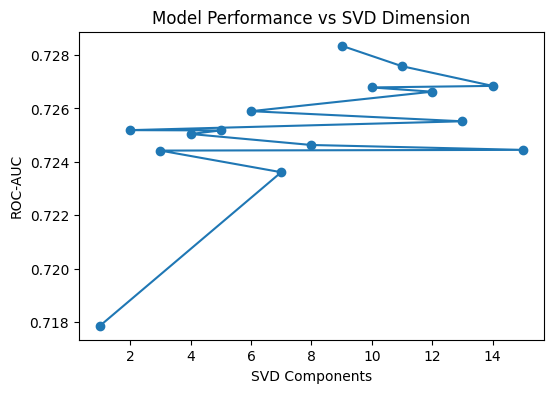

In [24]:
svd_results = find_best_svd_dimension(metadata_df)

print(svd_results)

plot_svd_performance(svd_results)

In [25]:
best_svd = svd_results.iloc[0]["n_svd"]
print(best_svd)

9.0


In [26]:
logistic_results = tune_logistic_with_svd(
    metadata_df,
    n_svd=9
)

print(logistic_results)

       C   roc_auc  avg_precision        f1    recall  precision    tn    fp  \
2   1.00  0.728594       0.697347  0.665750  0.689665   0.647864  60.4  34.4   
4  50.00  0.728446       0.696999  0.661901  0.685184   0.644327  60.2  34.6   
3  10.00  0.727984       0.696775  0.661901  0.685184   0.644327  60.2  34.6   
1   0.10  0.726524       0.697649  0.657261  0.678593   0.641039  60.0  34.8   
0   0.01  0.723156       0.694714  0.665016  0.682330   0.652687  61.4  33.4   

     fn    tp  
2  28.4  63.0  
4  28.8  62.6  
3  28.8  62.6  
1  29.2  62.2  
0  29.0  62.4  


In [27]:
best_C = logistic_results.iloc[0]["C"]
print(best_C)

1.0


In [28]:
clf, pipe_text = train_final_model(
    metadata_df,
    best_svd=9,
    best_C=1
)

In [29]:
test_metrics = evaluate_on_test(
    metadata_df,
    clf,
    pipe_text,
    best_svd
)

print(test_metrics)

{'roc_auc': 0.6907140214576397, 'avg_precision': 0.638586872154178, 'f1': 0.6434782608695652, 'recall': 0.7254901960784313, 'precision': 0.578125, 'tn': 26, 'fp': 27, 'fn': 14, 'tp': 37}


In [30]:
test = metadata_df[metadata_df[split_col] == "test"]

test_k = apply_note_embeddings_tfidf_svd(
    test,
    pipe_text,
    text_col=text_col
)

drop_cols = list(id_cols) + [target_col, split_col, text_col]

X_test = test_k.drop(columns=drop_cols, errors="ignore")
y_test = test_k[target_col]

threshold = find_threshold_for_target_recall(
    clf,
    X_test,
    y_test,
    target_recall=0.9
)

print(threshold)

0.3609322686680636


In [31]:
def evaluate_with_threshold(model, X, y, threshold=threshold):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y, probs),
        "avg_precision": average_precision_score(y, probs),
        "recall": recall_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

In [32]:
# Transform the test set with the fitted text pipeline
test = metadata_df[metadata_df[split_col] == "test"].copy()

test_k = apply_note_embeddings_tfidf_svd(
    test,
    pipe_text,
    text_col=text_col,
    out_prefix="note_svd"
)

drop_cols = list(id_cols) + [target_col, split_col, text_col]

X_test = test_k.drop(columns=drop_cols, errors="ignore")
y_test = test_k[target_col].astype(int).to_numpy()

test_metrics_thresh = evaluate_with_threshold(
    clf,
    X_test,
    y_test,
    threshold=threshold
)

print(test_metrics_thresh)

{'threshold': 0.3609322686680636, 'roc_auc': 0.6907140214576397, 'avg_precision': 0.638586872154178, 'recall': 0.9019607843137255, 'precision': 0.5822784810126582, 'f1': 0.7076923076923077, 'tn': 20, 'fp': 33, 'fn': 5, 'tp': 46}


In [33]:
default_metrics = evaluate_with_threshold(clf, X_test, y_test, threshold=0.50)
recall_metrics  = evaluate_with_threshold(clf, X_test, y_test, threshold=0.36)

print("Default 0.50 threshold:")
print(default_metrics)

print(f"\nRecall-tuned {threshold} threshold:")
print(recall_metrics)

Default 0.50 threshold:
{'threshold': 0.5, 'roc_auc': 0.6907140214576397, 'avg_precision': 0.638586872154178, 'recall': 0.7254901960784313, 'precision': 0.578125, 'f1': 0.6434782608695652, 'tn': 26, 'fp': 27, 'fn': 14, 'tp': 37}

Recall-tuned 0.3609322686680636 threshold:
{'threshold': 0.36, 'roc_auc': 0.6907140214576397, 'avg_precision': 0.638586872154178, 'recall': 0.9019607843137255, 'precision': 0.5822784810126582, 'f1': 0.7076923076923077, 'tn': 20, 'fp': 33, 'fn': 5, 'tp': 46}


In [36]:
def plot_confusion_matrix_with_threshold(model, X, y, threshold=0.36):
    
    # predicted probabilities
    probs = model.predict_proba(X)[:, 1]
    
    # apply custom threshold
    preds = (probs >= threshold).astype(int)

    # confusion matrix
    cm = confusion_matrix(y, preds)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot(cmap="Blues")
    
    plt.title(f"Confusion Matrix (threshold = {threshold})")
    plt.show()

    return cm

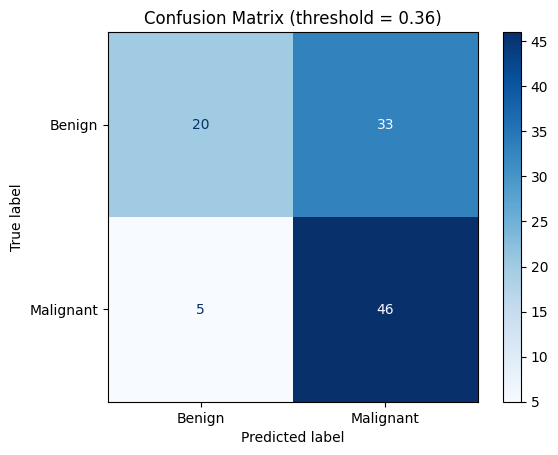

[[20 33]
 [ 5 46]]


In [45]:
cm = plot_confusion_matrix_with_threshold(
    clf,
    X_test,
    y_test,
    threshold=0.36
)

print(cm)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82a37552-7c08-4009-87b3-14968bdb21f2' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>